Basic setup

In [ ]:
import requests, sys, json

# Documentation: https://www.uniprot.org/help/api
WEBSITE_API = "https://rest.uniprot.org/"

# Documentation: https://www.ebi.ac.uk/proteins/api/doc/
PROTEINS_API = "https://www.ebi.ac.uk/proteins/api"

# Helper function to download data
def get_url(url, **kwargs):
  response = requests.get(url, **kwargs);

  if not response.ok:
    print(response.text)
    response.raise_for_status()
    sys.exit()

  return response

Basic search request

In [ ]:
r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=*")

data = r.json()

# print the number of results in the payload
n_results = len(data["results"])
print(f"Number of results: {n_results}\n")

# print all headers in the server response
for (key, value) in r.headers.items():
  print(f"{key}: {value}")

Number of results: 25

Vary: accept-encoding,x-uniprot-release,x-api-deployment-date,accept-encoding,accept, User-Agent
Cache-Control: public, max-age=43200
x-cache: miss cached
Content-Type: application/json
Content-Encoding: gzip
Access-Control-Allow-Credentials: true
Access-Control-Expose-Headers: Link, X-Total-Results, X-UniProt-Release, X-UniProt-Release-Date, X-API-Deployment-Date
X-API-Deployment-Date: 08-November-2023
Strict-Transport-Security: max-age=31536000; includeSubDomains
Date: Thu, 16 Nov 2023 11:13:02 GMT
Access-Control-Max-Age: 1728000
X-UniProt-Release: 2023_05
Link: <https://rest.uniprot.org/uniprotkb/search?query=%2A&cursor=1mkycb2xwxboutz9k0jj47l0ij8kh64qf3g1&size=25>; rel="next"
X-Total-Results: 251702059
Transfer-Encoding: chunked
Access-Control-Allow-Origin: *
Accept-Ranges: bytes
Connection: keep-alive
Access-Control-Allow-Methods: GET, PUT, POST, DELETE, PATCH, OPTIONS
Access-Control-Allow-Headers: DNT,Keep-Alive,User-Agent,X-Requested-With,If-Modified-Since

*Back to "search query format" slide*

Complex search request, paginated results

In [ ]:
# Search for gene parkin, in human
r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=Parkin AND (taxonomy_id:9606)")

data = r.json()

# get first page of results
total = r.headers.get("x-total-results")
page_total = len(data["results"])
print(f"total: {total}; page total: {page_total}")

# print(r.headers["Link"])

# print(r.links["next"]["url"])

# while there are next pages, paginate through them
while r.links.get("next", {}).get("url"):
  r = get_url(r.links["next"]["url"])

  data = r.json()

  total = r.headers.get("x-total-results")
  page_total = len(data["results"])
  print(f"total: {total}; page total: {page_total}")


total: 143; page total: 25
total: 143; page total: 25
total: 143; page total: 25
total: 143; page total: 25
total: 143; page total: 25
total: 143; page total: 18


Complex search request, stream

In [ ]:
# stream good for simplicity (no pagination), but...
#  - harder to follow progress
#  - harder to resume on failure
#  - not sorted by score
r = get_url(f"{WEBSITE_API}/uniprotkb/stream?query=parkin AND (taxonomy_id:9606)")

data = r.json()

total = len(data["results"])
print(f"total: {total}")

total: 143


Complex search request, other formats

In [ ]:
## No format defined, defaults to JSON
# r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=parkin AND (taxonomy_id:9606)&size=1")
## Specify a format, explicitely in the URL
# r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=parkin AND (taxonomy_id:9606)&size=1&format=xml")
## Specify a format, using request headers
# r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=parkin AND (taxonomy_id:9606)&size=1", headers={"Accept": "application/xml"})

# r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=parkin AND (taxonomy_id:9606)&format=list")
# r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=parkin AND (taxonomy_id:9606)&format=fasta")
r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=parkin AND (taxonomy_id:9606)&format=tsv")
print(r.text)

Entry	Entry Name	Reviewed	Protein names	Gene Names	Organism	Length
O60260	PRKN_HUMAN	reviewed	E3 ubiquitin-protein ligase parkin (Parkin) (EC 2.3.2.31) (Parkin RBR E3 ubiquitin-protein ligase) (Parkinson juvenile disease protein 2) (Parkinson disease protein 2)	PRKN PARK2	Homo sapiens (Human)	465
Q6NUN9	ZN746_HUMAN	reviewed	Zinc finger protein 746 (Parkin-interacting substrate) (PARIS)	ZNF746 PARIS	Homo sapiens (Human)	644
Q96M98	PACRG_HUMAN	reviewed	Parkin coregulated gene protein (Molecular chaperone/chaperonin-binding protein) (PARK2 coregulated gene protein)	PACRG GLUP	Homo sapiens (Human)	296
Q8IWT3	CUL9_HUMAN	reviewed	Cullin-9 (CUL-9) (UbcH7-associated protein 1) (p53-associated parkin-like cytoplasmic protein)	CUL9 H7AP1 KIAA0708 PARC	Homo sapiens (Human)	2517
X5DR79	X5DR79_HUMAN	unreviewed	E3 ubiquitin-protein ligase parkin (EC 2.3.2.31)	PARK2	Homo sapiens (Human)	465
O15354	GPR37_HUMAN	reviewed	Prosaposin receptor GPR37 (Endothelin B receptor-like protein 1) (ETBR-LP-1) (G-pro

Complex search request, customise column choice

In [ ]:
r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=parkin AND (taxonomy_id:9606)&fields=id,accession,length,cc_catalytic_activity&format=tsv")
print(r.text)

Entry Name	Entry	Length	Catalytic activity
PRKN_HUMAN	O60260	465	CATALYTIC ACTIVITY: Reaction=[E2 ubiquitin-conjugating enzyme]-S-ubiquitinyl-L-cysteine + [acceptor protein]-L-lysine = [E2 ubiquitin-conjugating enzyme]-L-cysteine + [acceptor protein]-N(6)-ubiquitinyl-L-lysine.; EC=2.3.2.31; Evidence={ECO:0000269|PubMed:23770887};
ZN746_HUMAN	Q6NUN9	644	
PACRG_HUMAN	Q96M98	296	
CUL9_HUMAN	Q8IWT3	2517	
X5DR79_HUMAN	X5DR79	465	CATALYTIC ACTIVITY: Reaction=[E2 ubiquitin-conjugating enzyme]-S-ubiquitinyl-L-cysteine + [acceptor protein]-L-lysine = [E2 ubiquitin-conjugating enzyme]-L-cysteine + [acceptor protein]-N(6)-ubiquitinyl-L-lysine.; EC=2.3.2.31; Evidence={ECO:0000256|ARBA:ARBA00001798};
GPR37_HUMAN	O15354	613	
UBP30_HUMAN	Q70CQ3	517	CATALYTIC ACTIVITY: Reaction=Thiol-dependent hydrolysis of ester, thioester, amide, peptide and isopeptide bonds formed by the C-terminal Gly of ubiquitin (a 76-residue protein attached to proteins as an intracellular targeting signal).; EC=3.4.19.12; Evid

*Back to "Retrieve an entry" slide*

Single entry

In [ ]:
# all of the entry
# r = get_url(f"{WEBSITE_API}/uniprotkb/O60260")
# only the catalytic activity comments
r = get_url(f"{WEBSITE_API}/uniprotkb/O60260?fields=cc_catalytic_activity")
print(json.dumps(r.json(), indent=2))

{
  "entryType": "UniProtKB reviewed (Swiss-Prot)",
  "primaryAccession": "O60260",
  "comments": [
    {
      "commentType": "CATALYTIC ACTIVITY",
      "reaction": {
        "name": "[E2 ubiquitin-conjugating enzyme]-S-ubiquitinyl-L-cysteine + [acceptor protein]-L-lysine = [E2 ubiquitin-conjugating enzyme]-L-cysteine + [acceptor protein]-N(6)-ubiquitinyl-L-lysine.",
        "ecNumber": "2.3.2.31",
        "evidences": [
          {
            "evidenceCode": "ECO:0000269",
            "source": "PubMed",
            "id": "23770887"
          }
        ]
      }
    }
  ]
}


*Back to "understanding annotation types" slide*

All isoforms of an entry

In [ ]:
# isoform info for PRKN_HUMAN (but not interesting to see)
# r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=O60260&fields=accession&includeIsoform=true&fields=cc_function,cc_subcellular_location,cc_ptm,sequence&format=tsv")
# isoform info for XBP1_HUMAN
r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=P17861&includeIsoform=true&fields=accession,cc_function,cc_subcellular_location,cc_ptm,sequence&format=tsv")

print(r.text)

Entry	Function [CC]	Subcellular location [CC]	Post-translational modification	Sequence
P17861	FUNCTION: Functions as a transcription factor during endoplasmic reticulum (ER) stress by regulating the unfolded protein response (UPR). Required for cardiac myogenesis and hepatogenesis during embryonic development, and the development of secretory tissues such as exocrine pancreas and salivary gland (By similarity). Involved in terminal differentiation of B lymphocytes to plasma cells and production of immunoglobulins (PubMed:11460154). Modulates the cellular response to ER stress in a PIK3R-dependent manner (PubMed:20348923). Binds to the cis-acting X box present in the promoter regions of major histocompatibility complex class II genes (PubMed:8349596). Involved in VEGF-induced endothelial cell (EC) proliferation and retinal blood vessel formation during embryonic development but also for angiogenesis in adult tissues under ischemic conditions. Functions also as a major regulator of the U

Natural variants information for an entry

In [ ]:
# entry info for O60260 / PRKN_HUMAN
# r = get_url(f"{WEBSITE_API}/uniprotkb/O60260")
# only the catalytic natural variants info
r = get_url(f"{WEBSITE_API}/uniprotkb/O60260?fields=ft_variant")
# print(json.dumps(r.json(), indent=2))
print(f"number of variants in UniProt website API: {len(r.json()['features'])}")

# using proteins API variation endpoint
r = get_url(f"{PROTEINS_API}/variation/O60260")
# print(json.dumps(r.json(), indent=2))
print(f"number of variants in Proteins API: {len(r.json()['features'])}")

number of variants in UniProt website API: 40
number of variants in Proteins API: 599


*Back to "retrieve and compare orthologs" slide*

Alignment flow

In [ ]:
# manually selected accessions
accessions = ["O60260", "Q7KTX7", "Q9WVS6", "Q9JK66"]
joined = ",".join(accessions)

r = get_url(f"{WEBSITE_API}/uniprotkb/accessions?accessions={joined}&format=fasta")
fasta = r.text
# print(fasta)

# submit align job using clustalo
r = requests.post("https://www.ebi.ac.uk/Tools/services/rest/clustalo/run", data={
    "email": "example@example.com",
    "iterations": 0,
    "outfmt": "clustal_num",
    "order": "aligned",
    "sequence": fasta
})
# documentation here https://www.ebi.ac.uk/seqdb/confluence/display/JDSAT/Clustal+Omega+Help+and+Documentation#ClustalOmegaHelpandDocumentation-RESTAPI

job_id = r.text
print(job_id)

# # # get job status
r = get_url(f"https://www.ebi.ac.uk/Tools/services/rest/clustalo/status/{job_id}")
print(r.text)

clustalo-R20231116-160548-0806-93611136-p1m
RUNNING


In [ ]:
r = get_url(f"https://www.ebi.ac.uk/Tools/services/rest/clustalo/status/{job_id}")
print(r.text)

RUNNING


In [ ]:
r = get_url(f"https://www.ebi.ac.uk/Tools/services/rest/clustalo/result/{job_id}/aln-clustal_num")
print(r.text)

CLUSTAL O(1.2.4) multiple sequence alignment


sp|Q7KTX7|PRKN_DROME      MSFIFKFIATFVRKMLELLQFGGKTLTHTLSIYVKTNTGKTLTVNLEPQWDIKNVKELVA	60
sp|O60260|PRKN_HUMAN      -----------------------------MIVFVRFNSSHGFPVEVDSDTSIFQLKEVVA	31
sp|Q9WVS6|PRKN_MOUSE      -----------------------------MIVFVRFNSSYGFPVEVDSDTSILQLKEVVA	31
sp|Q9JK66|PRKN_RAT        -----------------------------MIVFVRFNSSYGFPVEVDSDTSIFQLKEVVA	31
                                                       : ::*: *:.  : *::: : .* ::**:**

sp|Q7KTX7|PRKN_DROME      PQLGLQPDDLKIIFAGKELSDATTIEQCDLGQQSVLHAIRLRPPVQRQKIQSATLEEEEP	120
sp|O60260|PRKN_HUMAN      KRQGVPADQLRVIFAGKELRNDWTVQNCDLDQQSIVHIVQRP-WRKGQEMNAT--GGDDP	88
sp|Q9WVS6|PRKN_MOUSE      KRQGVPADQLRVIFAGKELPNHLTVQNCDLEQQSIVHIVQRP-RRRSHETNAS--GGDEP	88
sp|Q9JK66|PRKN_RAT        KRQGVPADQLRVIFAGKELQNHLTVQNCDLEQQSIVHIVQRP-QRKSHETNAS--GGDKP	88
                           : *:  *:*::******* :  *:::*** ***::* ::     : :: :::    :.*

sp|Q7KTX7|PRKN_DROME      SLSDEA--SKPL--------------NETL

*Back to "retrieve ID mapping service" slide*

ID mapping flow

In [ ]:
# manually selected accessions
accessions = ["O60260", "Q7KTX7", "Q9WVS6", "Q9JK66"]

# Send job to ID mapping endpoint
r = requests.post(f"{WEBSITE_API}/idmapping/run", data={
    "from": "UniProtKB_AC-ID",
    "to": "RefSeq_Nucleotide",
    "ids": accessions
})
job_id = r.json()['jobId']
print("job ID:", job_id)

r = get_url(f"{WEBSITE_API}/idmapping/status/{job_id}")
print(json.dumps(r.json(), indent=2))

job ID: a1e2f0093beee90a823830662be4c961d685852c
{
  "results": [
    {
      "from": "O60260",
      "to": "NM_004562.2"
    },
    {
      "from": "O60260",
      "to": "NM_013987.2"
    },
    {
      "from": "O60260",
      "to": "NM_013988.2"
    },
    {
      "from": "Q7KTX7",
      "to": "NM_168884.2"
    },
    {
      "from": "Q7KTX7",
      "to": "NM_168885.3"
    },
    {
      "from": "Q9WVS6",
      "to": "NM_001317726.1"
    },
    {
      "from": "Q9WVS6",
      "to": "NM_016694.4"
    },
    {
      "from": "Q9JK66",
      "to": "NM_020093.1"
    }
  ]
}


In [ ]:
r = get_url(f"{WEBSITE_API}/idmapping/status/{job_id}")
print(json.dumps(r.json(), indent=2))

{
  "results": [
    {
      "from": "O60260",
      "to": "NM_004562.2"
    },
    {
      "from": "O60260",
      "to": "NM_013987.2"
    },
    {
      "from": "O60260",
      "to": "NM_013988.2"
    },
    {
      "from": "Q7KTX7",
      "to": "NM_168884.2"
    },
    {
      "from": "Q7KTX7",
      "to": "NM_168885.3"
    },
    {
      "from": "Q9WVS6",
      "to": "NM_001317726.1"
    },
    {
      "from": "Q9WVS6",
      "to": "NM_016694.4"
    },
    {
      "from": "Q9JK66",
      "to": "NM_020093.1"
    }
  ]
}


*Back to last slides*

*Extra:* BLAST flow

In [ ]:
# get FASTA file
r = get_url(f"{WEBSITE_API}/uniprotkb/Q13496?format=fasta")
print(r.text)

# submit blast job
r = requests.post("https://www.ebi.ac.uk/Tools/services/rest/ncbiblast/run", data={
    "email": "example@example.com",
    "program": "blastp",
    "matrix": "BLOSUM62",
    "alignments": 250,
    "scores": 250,
    "exp": 10,
    "filter": "F",
    "gapalign": "true",
    "stype": "protein",
    "database": "uniprotkb_refprotswissprot",
    # restricted to Mammalia in this example
    "taxids": "40674",
    "sequence": r.text,
})
# documentation here https://www.ebi.ac.uk/seqdb/confluence/pages/viewpage.action?pageId=94147939#NCBIBLAST+HelpandDocumentation-RESTAPI

job_id = r.text
print(job_id)

# # get job status
r = get_url(f"https://www.ebi.ac.uk/Tools/services/rest/ncbiblast/status/{job_id}")
print(r.text)

>sp|Q13496|MTM1_HUMAN Myotubularin OS=Homo sapiens OX=9606 GN=MTM1 PE=1 SV=2
MASASTSKYNSHSLENESIKRTSRDGVNRDLTEAVPRLPGETLITDKEVIYICPFNGPIK
GRVYITNYRLYLRSLETDSSLILDVPLGVISRIEKMGGATSRGENSYGLDITCKDMRNLR
FALKQEGHSRRDMFEILTRYAFPLAHSLPLFAFLNEEKFNVDGWTVYNPVEEYRRQGLPN
HHWRITFINKCYELCDTYPALLVVPYRASDDDLRRVATFRSRNRIPVLSWIHPENKTVIV
RCSQPLVGMSGKRNKDDEKYLDVIRETNKQISKLTIYDARPSVNAVANKATGGGYESDDA
YHNAELFFLDIHNIHVMRESLKKVKDIVYPNVEESHWLSSLESTHWLEHIKLVLTGAIQV
ADKVSSGKSSVLVHCSDGWDRTAQLTSLAMLMLDSFYRSIEGFEILVQKEWISFGHKFAS
RIGHGDKNHTDADRSPIFLQFIDCVWQMSKQFPTAFEFNEQFLIIILDHLYSCRFGTFLF
NCESARERQKVTERTVSLWSLINSNKEKFKNPFYTKEINRVLYPVASMRHLELWVNYYIR
WNPRIKQQQPNPVEQRYMELLALRDEYIKRLEELQLANSAKLSDPPTSPSSPSQMMPHVQ
THF

ncbiblast-R20220927-140132-0953-82543592-p1m
RUNNING


In [ ]:
r = get_url(f"https://www.ebi.ac.uk/Tools/services/rest/ncbiblast/status/{job_id}")
print(r.text)

RUNNING


In [ ]:
r = get_url(f"https://www.ebi.ac.uk/Tools/services/rest/ncbiblast/result/{job_id}/out")
print(r.text)

BLASTP 2.9.0+


Reference: Stephen F. Altschul, Thomas L. Madden, Alejandro A.
Schaffer, Jinghui Zhang, Zheng Zhang, Webb Miller, and David J.
Lipman (1997), "Gapped BLAST and PSI-BLAST: a new generation of
protein database search programs", Nucleic Acids Res. 25:3389-3402.


Reference for composition-based statistics: Alejandro A. Schaffer,
L. Aravind, Thomas L. Madden, Sergei Shavirin, John L. Spouge, Yuri
I. Wolf, Eugene V. Koonin, and Stephen F. Altschul (2001),
"Improving the accuracy of PSI-BLAST protein database searches with
composition-based statistics and other refinements", Nucleic Acids
Res. 29:2994-3005.



Database: uniprotkb_refprotswissprot
           64,899,224 sequences; 25,452,742,688 total letters



Query= sp|Q13496|MTM1_HUMAN Myotubularin OS=Homo sapiens OX=9606 GN=MTM1
PE=1 SV=2

Length=603
                                                                      Score        E
Sequences producing significant alignments:                          (Bits)     Value

SP:

*Extra:* PTM retrievals

In [ ]:
from prettytable import PrettyTable

# Use B9FXV5 protein (Eukaryotic translation initiation factor 4G in rice)
accession = "B9FXV5"
# documentation https://www.ebi.ac.uk/proteins/api/doc/#!/proteomics-ptm/getByAccession
r = get_url(f"{PROTEINS_API}/proteomics-ptm/{accession}")

data = r.json()
# print(json.dumps(data, indent=2))

t = PrettyTable(['name', 'position', 'sources', 'id', 'confidence'])
table_data = []
for feature in data['features']:
  for ptm in feature['ptms']:
    for dbRef in ptm['dbReferences']:
      table_data.append(
          (ptm['name'],
           int(feature['begin']) + int(ptm['position']) - 1,
           ','.join(ptm['sources']),
           dbRef['id'],
           dbRef['properties']['Confidence score']))

# sort by "position" column
table_data = sorted(table_data, key=lambda x: x[1])
# filter by "confidence" column, only "Gold" values
table_data = filter(lambda x: x[4] == 'Gold', table_data)

t.add_rows(table_data)

print(t)


+-----------------+----------+-------------+-----------+------------+
|       name      | position |   sources   |     id    | confidence |
+-----------------+----------+-------------+-----------+------------+
| Phosphorylation |   902    | PTMeXchange | PXD004939 |    Gold    |
| Phosphorylation |   902    | PTMeXchange | PXD004705 |    Gold    |
| Phosphorylation |   902    | PTMeXchange | PXD002222 |    Gold    |
| Phosphorylation |   902    | PTMeXchange | PXD019291 |    Gold    |
| Phosphorylation |   1001   | PTMeXchange | PXD019291 |    Gold    |
| Phosphorylation |   1001   | PTMeXchange | PXD004939 |    Gold    |
| Phosphorylation |   1001   | PTMeXchange | PXD004705 |    Gold    |
| Phosphorylation |   1065   | PTMeXchange | PXD019291 |    Gold    |
| Phosphorylation |   1065   | PTMeXchange | PXD004939 |    Gold    |
| Phosphorylation |   1065   | PTMeXchange | PXD004705 |    Gold    |
| Phosphorylation |   1065   | PTMeXchange | PXD000923 |    Gold    |
| Phosphorylation | 

*Extra:* Visualisation example

*Note: These examples don't have a biological meaning, they are just there as an example in order to throw data on the screen! Please adjust accordingly to your interests*

In [ ]:
r = get_url(f"{WEBSITE_API}/uniprotkb/stream?query=(gene:MTM1)&fields=mass,reviewed,length,cc_catalytic_activity,annotation_score")
data = r.json()

print(len(data["results"]), data["results"][0])

839 {'entryType': 'UniProtKB unreviewed (TrEMBL)', 'primaryAccession': 'A0A024RC06', 'annotationScore': 5.0, 'comments': [{'commentType': 'CATALYTIC ACTIVITY', 'reaction': {'name': '1,2-dihexadecanoyl-sn-glycero-3-phospho-(1D-myo-inositol-3,5-phosphate) + H2O = 1,2-dihexadecanoyl-sn-glycero-3-phospho-(1D-myo-inositol-5-phosphate) + phosphate', 'reactionCrossReferences': [{'database': 'Rhea', 'id': 'RHEA:45636'}, {'database': 'ChEBI', 'id': 'CHEBI:15377'}, {'database': 'ChEBI', 'id': 'CHEBI:43474'}, {'database': 'ChEBI', 'id': 'CHEBI:78994'}, {'database': 'ChEBI', 'id': 'CHEBI:84968'}], 'evidences': [{'evidenceCode': 'ECO:0000256', 'source': 'ARBA', 'id': 'ARBA00023672'}]}}, {'commentType': 'CATALYTIC ACTIVITY', 'reaction': {'name': '1,2-dioctanoyl-sn-glycero-3-phospho-(1-D-myo-inositol-3-phosphate) + H2O = 1,2-dioctanoyl-sn-glycero-3-phospho-(1D-myo-inositol) + phosphate', 'reactionCrossReferences': [{'database': 'Rhea', 'id': 'RHEA:42328'}, {'database': 'ChEBI', 'id': 'CHEBI:15377'}, 

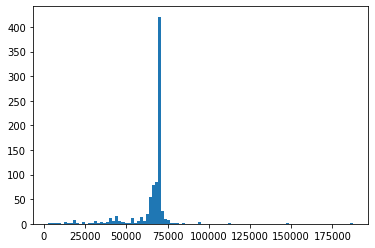

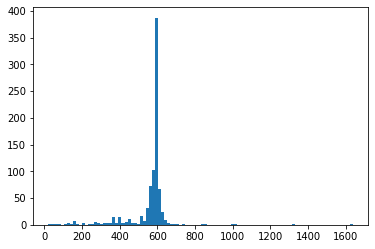

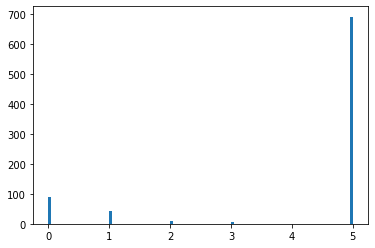

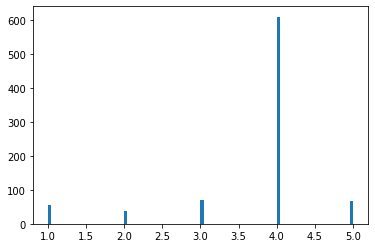

In [ ]:
import matplotlib.pyplot as plt

reviewed = ["grey" if "unreviewed" in entry["entryType"] else "gold" for entry in data["results"]]

mass = [entry["sequence"]["molWeight"] for entry in data["results"]]
plt.hist(mass, bins=100)
plt.show()

length = [entry["sequence"]["length"] for entry in data["results"]]
plt.hist(length, bins=100)
plt.show()

n_cat = [len(entry.get("comments", [])) for entry in data["results"]]
plt.hist(n_cat, bins=100)
plt.show()

score = [entry["annotationScore"] for entry in data["results"]]
plt.hist(score, bins=100)
plt.show()

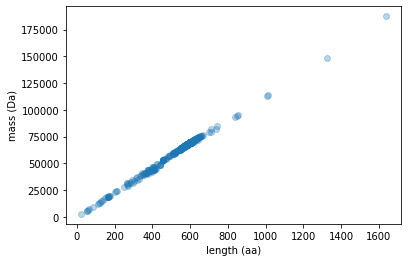

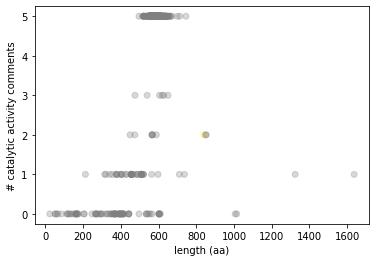

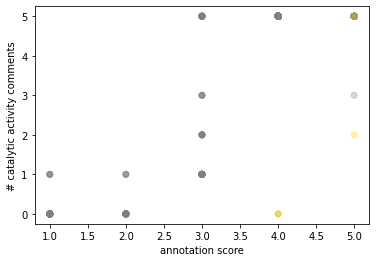

In [ ]:
plt.scatter(length, mass, alpha=0.3)
plt.xlabel("length (aa)")
plt.ylabel("mass (Da)")
plt.show()

plt.scatter(length, n_cat, c=reviewed, alpha=0.3)
plt.xlabel("length (aa)")
plt.ylabel("# catalytic activity comments")
plt.show()

plt.scatter(score, n_cat, c=reviewed, alpha=0.3)
plt.xlabel("annotation score")
plt.ylabel("# catalytic activity comments")
plt.show()